# Customer Churn Prediction


## 1. Imports

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Load Dataset & Identify Instances


In [73]:
df = pd.read_csv("Customer-Churn.CSV")

print(f" Shape : {df.shape}")
print(f" Instances : {df.shape[0]} rows")
print(f" Features : {df.shape[1]-1} columns (excl. target)")
print(f" Target : Churn")

df.head()

 Shape : (7043, 21)
 Instances : 7043 rows
 Features : 20 columns (excl. target)
 Target : Churn


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [74]:
print(" Feature Overview:")
for col in df.columns:
    print(f" {' ' if col=='Churn' else ' '} {col:<22} dtype={str(df[col].dtype):<10} "
          f"unique={df[col].nunique()}")

 Feature Overview:
   customerID             dtype=object     unique=7043
   gender                 dtype=object     unique=2
   SeniorCitizen          dtype=int64      unique=2
   Partner                dtype=object     unique=2
   Dependents             dtype=object     unique=2
   tenure                 dtype=int64      unique=73
   PhoneService           dtype=object     unique=2
   MultipleLines          dtype=object     unique=3
   InternetService        dtype=object     unique=3
   OnlineSecurity         dtype=object     unique=3
   OnlineBackup           dtype=object     unique=3
   DeviceProtection       dtype=object     unique=3
   TechSupport            dtype=object     unique=3
   StreamingTV            dtype=object     unique=3
   StreamingMovies        dtype=object     unique=3
   Contract               dtype=object     unique=3
   PaperlessBilling       dtype=object     unique=2
   PaymentMethod          dtype=object     unique=4
   MonthlyCharges         dtype=float64  

## 3. Data Cleaning & Preprocessing

In [75]:
# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
# Normalise column names
df.columns = df.columns.str.lower().str.replace(' ', '_')
string_cols = list(df.dtypes[df.dtypes == 'object'].index)
for col in string_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')
# Encode target
df['churn'] = (df['churn'] == 'yes').astype(int)
# Binary yes/no cols
for col in ['partner','dependents','phoneservice','paperlessbilling']:
    df[col] = (df[col] == 'yes').astype(int)
# Internet-service sub-features
for col in ['onlinesecurity','onlinebackup','deviceprotection', 'techsupport','streamingtv','streamingmovies','multiplelines']:
    df[col] = df[col].replace({'no_internet_service':'no','no_phone_service':'no'})
    df[col] = (df[col] == 'yes').astype(int)
df['gender'] = (df['gender'] == 'male').astype(int)
df['contract'] = df['contract'].map({'month-to-month':0,'one_year':1,'two_year':2})
df = pd.get_dummies(df, columns=['paymentmethod'], prefix='pay', drop_first=True)
df = pd.get_dummies(df, columns=['internetservice'], prefix='svc', drop_first=True)
df = df.drop('customerid', axis=1)
print(" Preprocessing done. Shape:", df.shape)
df.head().T

 Preprocessing done. Shape: (7043, 23)


,0,1,2,3,4
gender,0,1,1,1,0
seniorcitizen,0,0,0,0,0
partner,1,0,0,0,0
dependents,0,0,0,0,0
tenure,1,34,2,45,2
phoneservice,0,1,1,0,1
multiplelines,0,0,0,0,0
onlinesecurity,0,1,1,1,0
onlinebackup,1,0,1,0,0
deviceprotection,0,1,0,1,0


## 4. Display Content of Dataset

In [76]:
print(" Statistical Summary:")
df.describe().T

 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
gender,7043.0,0.504756,0.500013,0.00,0.00,1.00,1.00,1.00
seniorcitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
partner,7043.0,0.483033,0.499748,0.00,0.00,0.00,1.00,1.00
dependents,7043.0,0.299588,0.458110,0.00,0.00,0.00,1.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
phoneservice,7043.0,0.903166,0.295752,0.00,1.00,1.00,1.00,1.00
multiplelines,7043.0,0.421837,0.493888,0.00,0.00,0.00,1.00,1.00
onlinesecurity,7043.0,0.286668,0.452237,0.00,0.00,0.00,1.00,1.00
onlinebackup,7043.0,0.344881,0.475363,0.00,0.00,0.00,1.00,1.00
deviceprotection,7043.0,0.343888,0.475038,0.00,0.00,0.00,1.00,1.00


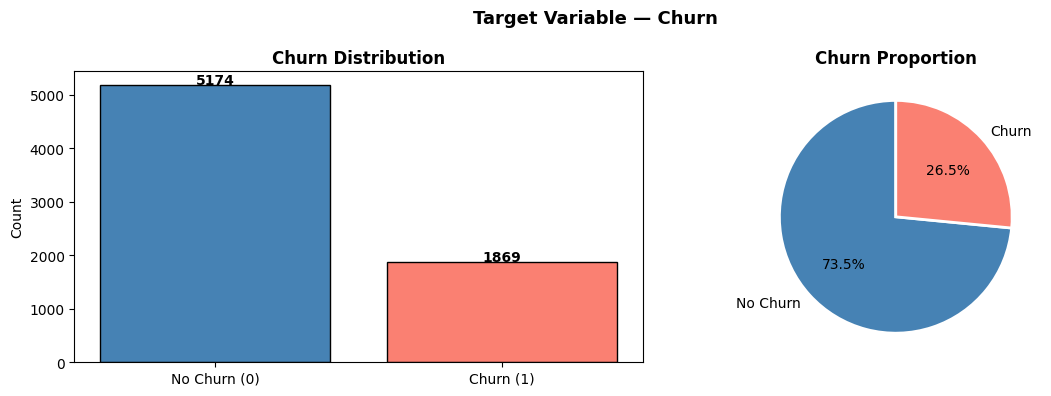

In [77]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['churn'].value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], counts.values, color=['steelblue','salmon'], edgecolor='black')
axes[0].set_title('Churn Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=['No Churn','Churn'], autopct='%1.1f%%', colors=['steelblue','salmon'], startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Churn Proportion', fontweight='bold')
plt.suptitle('Target Variable — Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## IQR Outlier Analysis


In [78]:
numeric_cols = ['tenure', 'monthlycharges', 'totalcharges']
print("=" * 68)
print(f"{'Column':<18}{'Q1':>7}{'Q3':>7}{'IQR':>7}{'Lower':>9}{'Upper':>9}{'Outliers':>11}")
print("=" * 68)
iqr_info = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo = Q1 - 1.5 * IQR
    hi = Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    iqr_info[col] = dict(Q1=Q1, Q3=Q3, IQR=IQR, lower=lo, upper=hi, n_out=n_out)
    print(f"{col:<18}{Q1:>7.2f}{Q3:>7.2f}{IQR:>7.2f}{lo:>9.2f}{hi:>9.2f}{n_out:>11}")
print("=" * 68)

Column                 Q1     Q3    IQR    Lower    Upper   Outliers
tenure               9.00  55.00  46.00   -60.00   124.00          0
monthlycharges      35.50  89.85  54.35   -46.02   171.38          0
totalcharges       398.553786.603388.05 -4683.52  8868.67          0


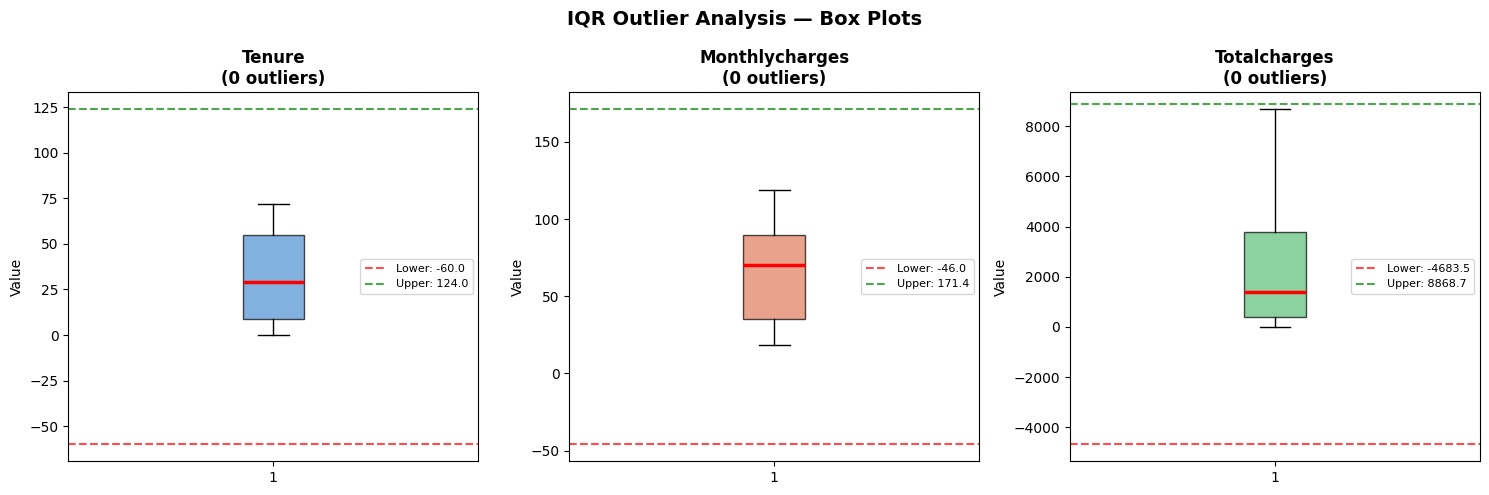

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('IQR Outlier Analysis — Box Plots', fontsize=14, fontweight='bold')
colors = ['#4e91d2', '#e07b5a', '#5cbf7a']
for ax, col, c in zip(axes, numeric_cols, colors):
    info = iqr_info[col]
    ax.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor=c, color='black', alpha=0.7), medianprops=dict(color='red', linewidth=2.5), flierprops=dict(marker='o', color='orange', markeredgecolor='darkorange', markersize=3, alpha=0.5), whiskerprops=dict(color='black'), capprops=dict(color='black'))
    ax.axhline(info['lower'], color='red', linestyle='--', alpha=0.7, label=f"Lower: {info['lower']:.1f}")
    ax.axhline(info['upper'], color='green', linestyle='--', alpha=0.7, label=f"Upper: {info['upper']:.1f}")
    ax.set_title(f"{col.capitalize()}\n({info['n_out']} outliers)", fontweight='bold')
    ax.set_ylabel('Value')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Correlation Analysis


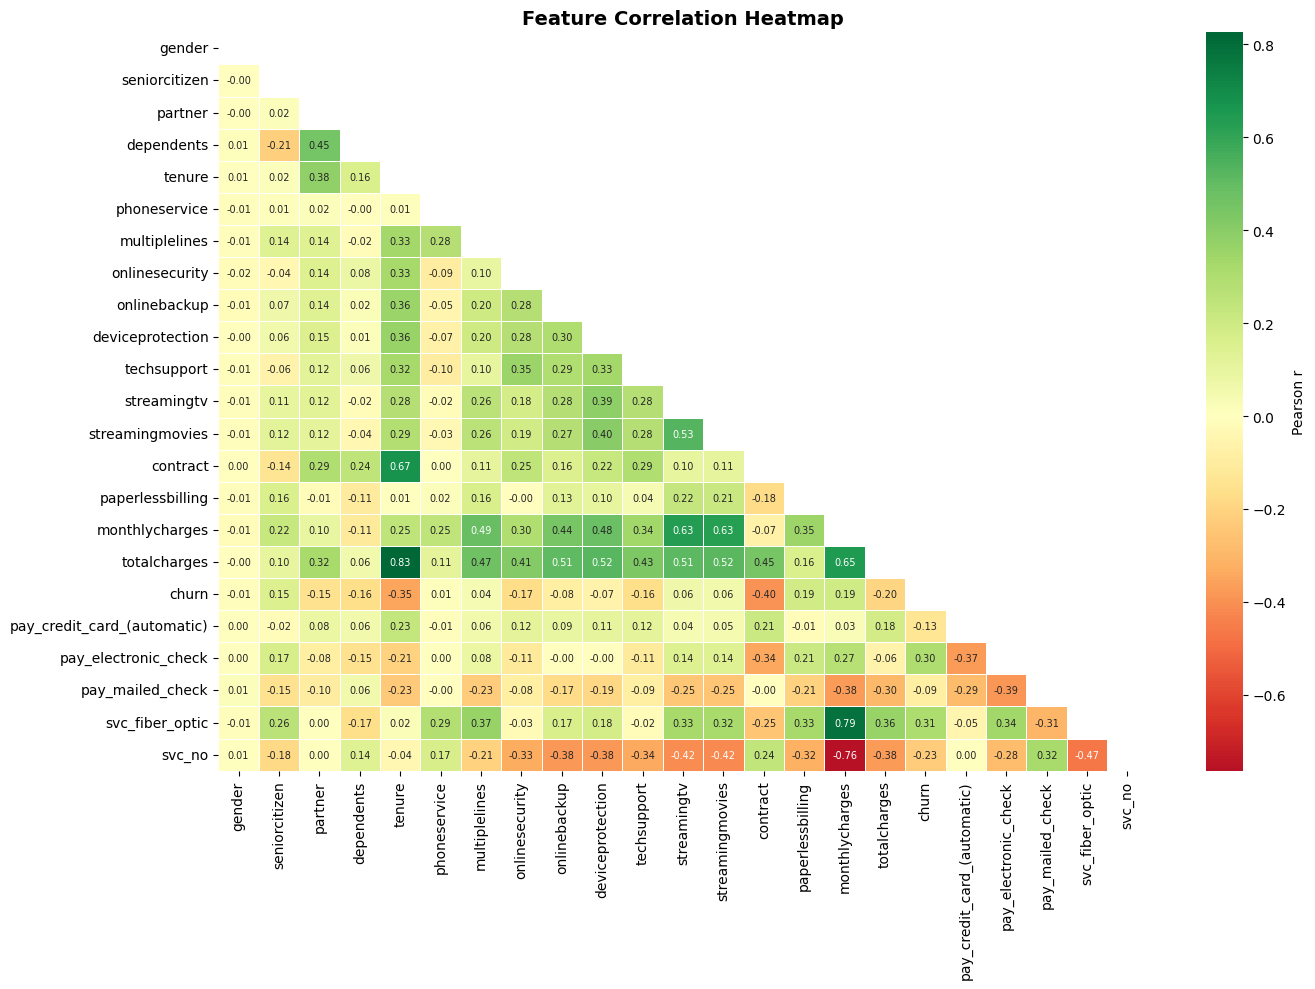

In [80]:
corr = df.corr()
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={'size': 7}, cbar_kws={'label': 'Pearson r'})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

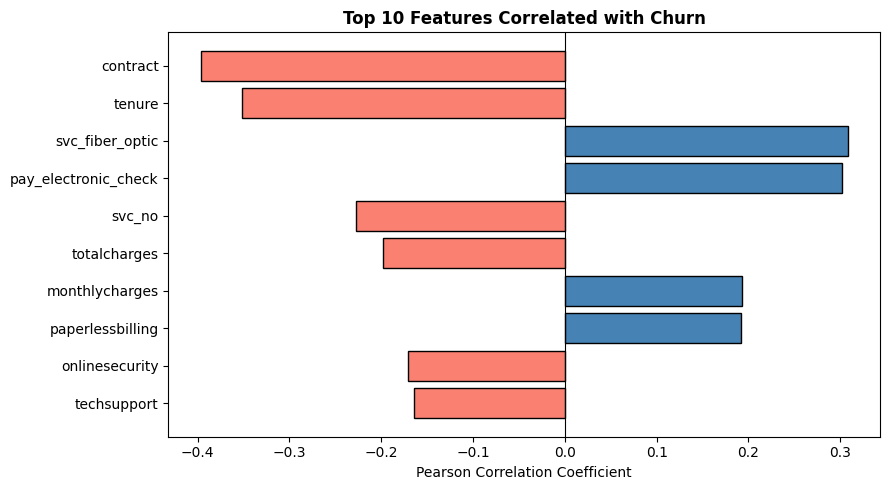


 Top correlations with Churn:
contract               -0.396713
tenure                 -0.352229
svc_fiber_optic         0.308020
pay_electronic_check    0.301919
svc_no                 -0.227890
totalcharges           -0.198324
monthlycharges          0.193356
paperlessbilling        0.191825
onlinesecurity         -0.171226
techsupport            -0.164674


In [81]:
churn_corr = corr['churn'].drop('churn').sort_values(key=abs, ascending=False)
top10 = churn_corr.head(10)
plt.figure(figsize=(9, 5))
colors = ['salmon' if v < 0 else 'steelblue' for v in top10.values]
plt.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1], edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 Features Correlated with Churn', fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()
print("\n Top correlations with Churn:")
print(top10.to_string())

## 7. Train/Test Split


In [82]:
X = df.drop('churn', axis=1)
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


## 8. Apply Algorithms

In [83]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    print(f"\n{'='*50}")
    print(f" {name}")
    print(f"{'='*50}")
    print(f" Accuracy : {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['No Churn','Churn']))
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    plt.title(f'{name} — Confusion Matrix', fontweight='bold')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()
    return acc
results = {}

### 9. Decision Tree


 Decision Tree
 Accuracy : 79.91%

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.87      1035
       Churn       0.63      0.58      0.61       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.79      0.80      0.80      1409



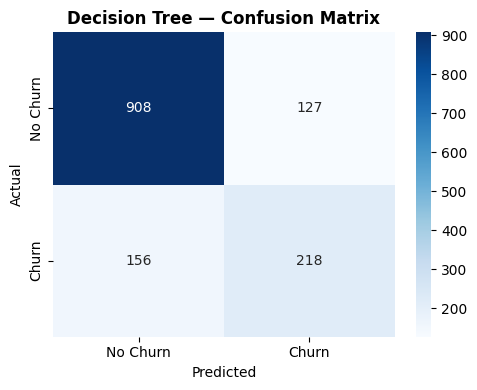

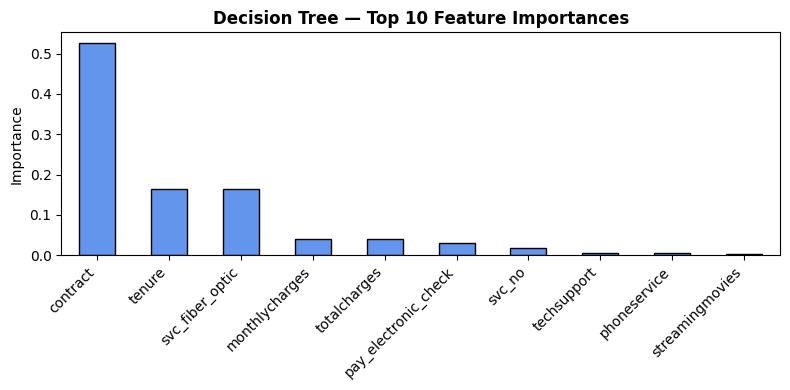

In [84]:
from sklearn.tree import DecisionTreeClassifier, export_text
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
results['Decision Tree'] = evaluate_model(
    'Decision Tree', dt, X_train, y_train, X_test, y_test)

# Feature importance
fi = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
fi.plot(kind='bar', color='cornflowerblue', edgecolor='black')
plt.title('Decision Tree — Top 10 Feature Importances', fontweight='bold')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

## 10. Pickle file

In [85]:
import pickle

# Save the trained Decision Tree model to a .pkl file
model_filename = 'decision_tree_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(dt, file)

print(f" Decision Tree model saved to '{model_filename}'")

 Decision Tree model saved to 'decision_tree_model.pkl'
